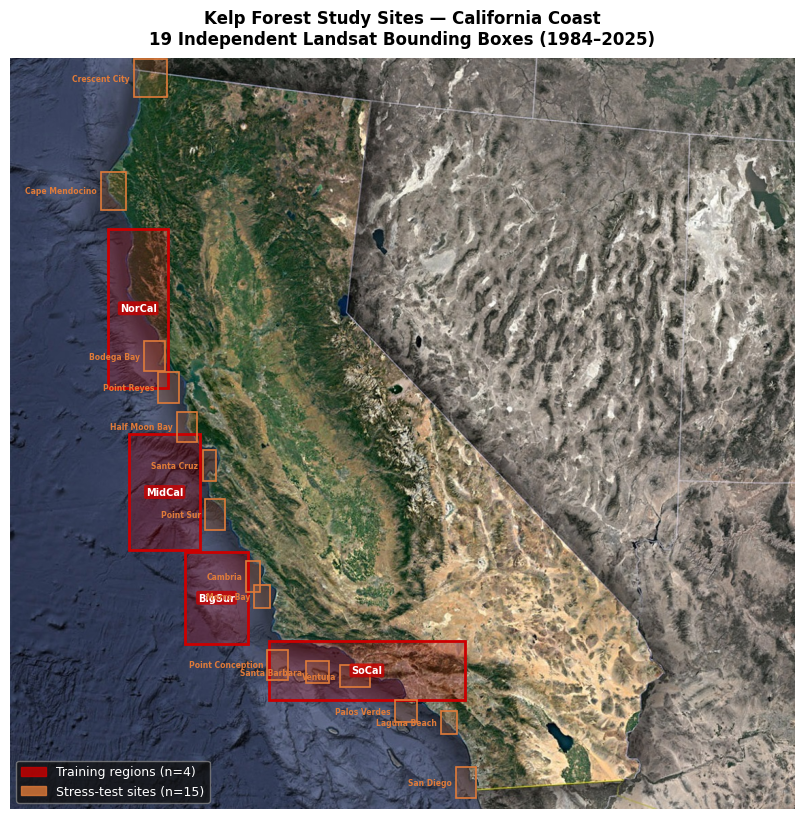

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/supplementary/california_bbox_map.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path
from numpy.linalg import lstsq

# ── Load image ───────────────────────────────────────────────
IMG_PATH = Path('/Users/tonylin/Documents/kelp_project/2_NOTEBOOKS/TESTS/california coast map.jpg')
img = np.array(Image.open(IMG_PATH))
img_h, img_w = img.shape[:2]

# ── Affine calibration ───────────────────────────────────────
# Anchors derived from actual coastline pixel detection
anchors_geo = [
    (41.8, -124.2),   # Crescent City
    (38.4, -123.1),   # Bodega Bay
    (36.6, -121.9),   # Monterey
    (34.4, -119.7),   # Santa Barbara
    (32.8, -117.2),   # San Diego
]
anchors_px = [
    (189,   28),
    (228,  432),
    (299,  647),
    (417,  908),
    (687, 1060),
]

geo = np.array([[a[0], a[1], 1] for a in anchors_geo])
px  = np.array(anchors_px)
Ax, _, _, _ = lstsq(geo, px[:, 0], rcond=None)
Ay, _, _, _ = lstsq(geo, px[:, 1], rcond=None)

def geo_to_px(lat, lon):
    x = Ax[0]*lat + Ax[1]*lon + Ax[2]
    y = Ay[0]*lat + Ay[1]*lon + Ay[2]
    return x, y

# ── Bounding boxes ───────────────────────────────────────────
BBOXES = [
    # 4 main training regions — RED
    ('NorCal',  38.0, 40.0, -124.2, -122.8,  True),
    ('MidCal',  36.0, 37.5, -123.2, -121.8,  True),
    ('BigSur',  34.8, 36.0, -122.0, -120.8,  True),
    ('SoCal',   33.8, 34.8, -120.5, -117.5,  True),
    # 15 stress test sites — orange
    ('Crescent City',    41.5, 42.0, -124.4, -123.8,  False),
    ('Cape Mendocino',   40.2, 40.7, -124.5, -124.0,  False),
    ('Bodega Bay',       38.2, 38.6, -123.3, -122.9,  False),
    ('Point Reyes',      37.8, 38.2, -123.0, -122.6,  False),
    ('Half Moon Bay',    37.3, 37.7, -122.6, -122.2,  False),
    ('Santa Cruz',       36.8, 37.2, -122.1, -121.8,  False),
    ('Point Sur',        36.2, 36.6, -121.9, -121.5,  False),
    ('Cambria',          35.4, 35.8, -121.1, -120.8,  False),
    ('Morro Bay',        35.2, 35.5, -120.9, -120.6,  False),
    ('Point Conception', 34.3, 34.7, -120.5, -120.1,  False),
    ('Santa Barbara',    34.2, 34.5, -119.9, -119.5,  False),
    ('Ventura',          34.1, 34.4, -119.4, -118.9,  False),
    ('Palos Verdes',     33.6, 33.9, -118.5, -118.1,  False),
    ('Laguna Beach',     33.4, 33.7, -117.8, -117.5,  False),
    ('San Diego',        32.6, 33.0, -117.4, -117.0,  False),
]

COLOR_TRAIN = '#CC0000'
COLOR_TEST  = '#E07B39'

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, int(9 * img_h / img_w)))
fig.patch.set_visible(False)
ax.imshow(img, extent=[0, img_w, img_h, 0], aspect='equal')
ax.axis('off')

for (name, la0, la1, lo0, lo1, is_train) in BBOXES:
    x0, y0 = geo_to_px(la1, lo0)
    x1, y1 = geo_to_px(la0, lo1)
    w_px = x1 - x0
    h_px = y1 - y0

    color = COLOR_TRAIN if is_train else COLOR_TEST
    lw    = 2.0          if is_train else 1.2
    alpha = 0.22         if is_train else 0.20

    ax.add_patch(mpatches.Rectangle(
        (x0, y0), w_px, h_px,
        linewidth=0, facecolor=color, alpha=alpha, zorder=3))
    ax.add_patch(mpatches.Rectangle(
        (x0, y0), w_px, h_px,
        linewidth=lw, edgecolor=color, facecolor='none', zorder=4))

    cx = (x0 + x1) / 2
    cy = (y0 + y1) / 2
    if is_train:
        ax.text(cx, cy, name,
                fontsize=7, fontweight='bold', color='white',
                ha='center', va='center', zorder=5,
                bbox=dict(boxstyle='round,pad=0.2',
                          facecolor=color, alpha=0.8, edgecolor='none'))
    else:
        ax.text(x0 - 6, cy, name,
                fontsize=5.5, fontweight='bold', color=color,
                ha='right', va='center', zorder=5)

# ── Legend ───────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=COLOR_TRAIN, edgecolor=COLOR_TRAIN,
                   alpha=0.8, label='Training regions (n=4)'),
    mpatches.Patch(facecolor=COLOR_TEST,  edgecolor=COLOR_TEST,
                   alpha=0.8, label='Stress-test sites (n=15)'),
]
ax.legend(handles=legend_elements,
          loc='lower left', fontsize=9,
          framealpha=0.75, edgecolor='#888888',
          facecolor='#111111', labelcolor='white')

ax.set_title(
    'Kelp Forest Study Sites — California Coast\n'
    '19 Independent Landsat Bounding Boxes (1984–2025)',
    fontsize=12, fontweight='bold', pad=10)

plt.tight_layout(pad=0)

out = Path('/Users/tonylin/Documents/kelp_project/5_FIGURES/supplementary/california_bbox_map.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')